## Cell 1 — Imports and config
Imports libraries and sets all editable paths for Fitzpatrick + DermNet preprocessing.

In [8]:
%matplotlib inline

from pathlib import Path
from datetime import datetime
from collections import Counter
from typing import Dict, List, Tuple
import re

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

FITZ_CSV = Path('data/Fitzpatrick17k-C.csv')
FITZ_MAPPING = Path('data/Fitzpatrick17k_DiagnosisMapping.xlsx')
FITZ_ABBR_MAP = Path('data/fitz_diag_abbrev_mapping.csv')
FITZ_IMG_DIR = Path('data/Fitzpatrick17k_CategorizedAbbrvs/Categorized_AbbrvName')
DERMNET_DIR = Path('data/DermNet')
OUTPUT_DIR = Path('stage3_output')

UNIFIED_CLASSES = [
    'MEL','BCC','SCC','AK','NEV','BKL','DF','VASC','SEK',
    'TINEA','PSORIASIS','VITILIGO','MELASMA','FUNGAL','ECZEMA','URTICARIA'
]
UNKNOWN_LABEL = 'UNKNOWN'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Config ready. All paths set.')
print('[INFO] FITZ CSV:', FITZ_CSV)
print('[INFO] FITZ IMG DIR:', FITZ_IMG_DIR)
print('[INFO] DERMNET DIR:', DERMNET_DIR)

Config ready. All paths set.
[INFO] FITZ CSV: data\Fitzpatrick17k-C.csv
[INFO] FITZ IMG DIR: data\Fitzpatrick17k_CategorizedAbbrvs\Categorized_AbbrvName
[INFO] DERMNET DIR: data\DermNet


## Cell 2 — Inspect Fitzpatrick CSV
Loads Fitz CSV and prints schema, distributions, and missingness.

In [9]:
df_fitz = pd.read_csv(FITZ_CSV)
print('[INFO] Shape:', df_fitz.shape)
print('[INFO] Columns:', list(df_fitz.columns))
display(df_fitz.head(3))

diag_col = 'label' if 'label' in df_fitz.columns else ('diagnosis' if 'diagnosis' in df_fitz.columns else None)
fst_col = 'fitzpatrick' if 'fitzpatrick' in df_fitz.columns else ('fst' if 'fst' in df_fitz.columns else None)

if diag_col:
    print('[INFO] Diagnosis column:', diag_col)
    print(df_fitz[diag_col].astype(str).value_counts(dropna=False).head(25))
    print('[INFO] Total unique diagnosis labels found:', df_fitz[diag_col].astype(str).nunique())

if fst_col:
    print('[INFO] FST column:', fst_col)
    print(df_fitz[fst_col].value_counts(dropna=False).sort_index())

print('[INFO] Missing values per column:')
print(df_fitz.isna().sum())

if 'split' in df_fitz.columns:
    print('[INFO] split column exists:')
    print(df_fitz['split'].astype(str).value_counts(dropna=False))
elif 'partition' in df_fitz.columns:
    print('[INFO] partition column exists (used as split):')
    print(df_fitz['partition'].astype(str).value_counts(dropna=False))
else:
    print('[INFO] No split/partition column found.')

[INFO] Shape: (11394, 15)
[INFO] Columns: ['filepath', 'filename', 'diag', 'fst', 'partition', 'md5hash', 'fitzpatrick', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum', 'orig_img_name', 'new_img_name']


,filepath,filename,diag,fst,partition,md5hash,fitzpatrick,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,orig_img_name,new_img_name
0,ne-de_361/ne-de_f2_61_3a96728f.jpg,ne-de_f2_61_3a96728f,ne-de,2,train,3a96728fb161fc25b3597d3996dc4e4a,2,neutrophilic dermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppyode...,3a96728fb161fc25b3597d3996dc4e4a.jpg,ne-de_f2_61_3a96728f.jpg
1,lu-er_410/lu-er_f1_89_07be6be3.jpg,lu-er_f1_89_07be6be3,lu-er,1,train,07be6be3cbebd04ff9bfcab50b75378b,1,lupus erythematosus,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicssubac...,07be6be3cbebd04ff9bfcab50b75378b.jpg,lu-er_f1_89_07be6be3.jpg
2,me_261/me_f0_194_72bcd875.jpg,me_f0_194_72bcd875,me,0,train,72bcd875e7a573b4139883059e69328d,-1,melanoma,malignant melanoma,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=4264,httpwwwatlasdermatologicocombrimgimageId4264.jpg,72bcd875e7a573b4139883059e69328d.jpg,me_f0_194_72bcd875.jpg


[INFO] Diagnosis column: label
label
psoriasis                      534
basal cell carcinoma           412
lichen planus                  377
squamous cell carcinoma        372
allergic contact dermatitis    314
acne vulgaris                  299
sarcoidosis                    257
lupus erythematosus            257
scleroderma                    246
neutrophilic dermatoses        244
photodermatoses                242
scabies                        203
folliculitis                   182
eczema                         176
melanoma                       176
pityriasis rubra pilaris       176
drug eruption                  157
erythema multiforme            154
mycosis fungoides              143
actinic keratosis              142
dermatomyositis                135
urticaria                      134
dariers disease                130
granuloma annulare             130
pityriasis rosea               123
Name: count, dtype: int64
[INFO] Total unique diagnosis labels found: 114
[INFO] FST col

## Cell 3 — Load and inspect diagnosis mapping
Loads mapping references and builds FITZ_DIAGNOSIS_MAP from full diagnosis text.

In [10]:
if FITZ_MAPPING.exists():
    wb = openpyxl.load_workbook(FITZ_MAPPING, read_only=True)
    print('[INFO] Mapping workbook sheets:', wb.sheetnames)
    df_map_xlsx = pd.read_excel(FITZ_MAPPING)
    print('[INFO] XLSX columns:', list(df_map_xlsx.columns))
    display(df_map_xlsx)
else:
    print('[WARN] FITZ_MAPPING not found')

if FITZ_ABBR_MAP.exists():
    df_abbr = pd.read_csv(FITZ_ABBR_MAP)
    print('[INFO] Abbreviation mapping columns:', list(df_abbr.columns))
    display(df_abbr.head())
else:
    df_abbr = pd.DataFrame()
    print('[WARN] FITZ_ABBR_MAP not found')

def map_diagnosis_keyword(raw: str) -> str:
    s = str(raw).strip().lower()
    if 'melanoma' in s: return 'MEL'
    if 'basal cell' in s: return 'BCC'
    if 'squamous' in s: return 'SCC'
    if 'actinic keratos' in s: return 'AK'
    if any(k in s for k in ['nevus','nevi','mole']): return 'NEV'
    if 'seborrheic keratos' in s: return 'BKL'
    if 'dermatofibroma' in s: return 'DF'
    if any(k in s for k in ['vascular','angioma','hemangioma']): return 'VASC'
    if 'sebaceous keratos' in s or 'keratosis sebaceous' in s: return 'SEK'
    if any(k in s for k in ['tinea','ringworm']): return 'TINEA'
    if 'psoriasis' in s: return 'PSORIASIS'
    if 'vitiligo' in s: return 'VITILIGO'
    if any(k in s for k in ['melasma','chloasma']): return 'MELASMA'
    if any(k in s for k in ['fungal','candida','onychomycosis']): return 'FUNGAL'
    if any(k in s for k in ['eczema','dermatitis','atopic']): return 'ECZEMA'
    if any(k in s for k in ['urticaria','hives']): return 'URTICARIA'
    return UNKNOWN_LABEL

source_labels = sorted(df_fitz['label'].astype(str).dropna().str.strip().unique().tolist())
FITZ_DIAGNOSIS_MAP = {lbl: map_diagnosis_keyword(lbl) for lbl in source_labels}

df_map_summary = pd.DataFrame({'raw label': list(FITZ_DIAGNOSIS_MAP.keys()), 'mapped to': list(FITZ_DIAGNOSIS_MAP.values())})
display(df_map_summary)
print('[INFO] Successfully mapped:', int((df_map_summary['mapped to'] != UNKNOWN_LABEL).sum()))
print('[INFO] UNKNOWN mapped:', int((df_map_summary['mapped to'] == UNKNOWN_LABEL).sum()))
print('[NOTE] Review mapping table and edit rules manually in this cell if needed.')

[INFO] Mapping workbook sheets: ['Mapping']
[INFO] XLSX columns: ['Abbreviated \nDiagnosis Label', 'Diagnosis Label', 'ICD-11 Name', 'ICD-11 Code', 'ICD-11 URI', 'ICD-11 Notes', 'ICD-11 Coding Tool', 'ICD-11 Classification of \nDermatological Diseases', 'SNOMED-CT Label', 'SCTID', 'Link', 'SNOMED-CT Notes']


,Abbreviated \nDiagnosis Label,Diagnosis Label,ICD-11 Name,ICD-11 Code,ICD-11 URI,ICD-11 Notes,ICD-11 Coding Tool,ICD-11 Classification of \nDermatological Diseases,SNOMED-CT Label,SCTID,Link,SNOMED-CT Notes
0,ac-ni,acanthosis nigricans,ED51.0,Acanthosis nigricans,http://id.who.int/icd/entity/71488193,NaN,NaN,NaN,Acanthosis nigricans (disorder),402599005.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
1,ac,acne,ED80,Acne,http://id.who.int/icd/entity/1892393023,NaN,NaN,NaN,Acne (disorder),11381005.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
2,ac-vu,acne vulgaris,ED80.Z,"Acne, unspecified",NaN,NaN,NaN,NaN,Acne vulgaris (disorder),88616000.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
3,ac-au-bu-di-ge,acquired autoimmune bullous diseaseherpes gest...,NaN,NaN,NaN,Second half matches to JA65.10 Herpes gestatio...,—,—,NaN,NaN,NaN,First half matches to Anti-p200 pemphigoid and...
4,ac-en,acrodermatitis enteropathica,5C64.20,Acrodermatitis enteropathica,http://id.who.int/icd/entity/1813939482,NaN,NaN,NaN,Hereditary acrodermatitis enteropathica (disor...,37702000.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
109,ur,urticaria,NaN,NaN,NaN,Many subtypes.,—,—,Urticaria (disorder),126485001.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
110,ur-pi,urticaria pigmentosa,2A21.10,Urticaria pigmentosa,http://id.who.int/icd/entity/245322245,NaN,NaN,NaN,NaN,NaN,NaN,"Many subtypes: bullous, adult form, and infant..."
111,vi,vitiligo,ED63.0,Vitiligo,http://id.who.int/icd/entity/1894744640,NaN,NaN,NaN,Vitiligo (disorder),56727007.0,https://browser.ihtsdotools.org/?perspective=f...,NaN
112,xa,xanthomas,NaN,NaN,NaN,Many subtypes.,—,—,Xanthomatosis (disorder),63103006.0,https://browser.ihtsdotools.org/?perspective=f...,Match for Xanthoma.


[INFO] Abbreviation mapping columns: ['Diagnosis Label', 'Abbreviated Diagnosis Label']


,Diagnosis Label,Abbreviated Diagnosis Label
0,acanthosis nigricans,ac-ni
1,acne,ac
2,acne vulgaris,ac-vu
3,acquired autoimmune bullous diseaseherpes gest...,ac-au-bu-di-ge
4,acrodermatitis enteropathica,ac-en


,raw label,mapped to
0,acanthosis nigricans,UNKNOWN
1,acne,UNKNOWN
2,acne vulgaris,UNKNOWN
3,acquired autoimmune bullous diseaseherpes gest...,UNKNOWN
4,acrodermatitis enteropathica,ECZEMA
...,...,...
109,urticaria,URTICARIA
110,urticaria pigmentosa,URTICARIA
111,vitiligo,VITILIGO
112,xanthomas,UNKNOWN


[INFO] Successfully mapped: 30
[INFO] UNKNOWN mapped: 84
[NOTE] Review mapping table and edit rules manually in this cell if needed.


## Cell 4 — Use local Fitzpatrick images
Skips web download and collects image paths from extracted ZIP folder.

In [11]:
fitz_downloaded_paths = [str(p) for p in FITZ_IMG_DIR.rglob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
failed_downloads = []
download_stats = {'attempted': len(fitz_downloaded_paths), 'downloaded': 0, 'existed': len(fitz_downloaded_paths), 'failed': 0, 'excluded_unknown': 0}
(OUTPUT_DIR / 'failed_downloads.txt').write_text('', encoding='utf-8')
print('[INFO] Download step skipped (using local ZIP images).')
print('[INFO] Local Fitz images found:', len(fitz_downloaded_paths))

[INFO] Download step skipped (using local ZIP images).
[INFO] Local Fitz images found: 16577


## Cell 5 — Validate Fitzpatrick images
Validates local Fitz images and previews random valid samples.

Validating Fitz images: 100%|██████████| 16577/16577 [03:01<00:00, 91.52it/s] 


[INFO] Total checked: 16577
[INFO] Valid count: 16577
[INFO] Invalid count: 0
[INFO] Invalid breakdown: {'corrupt files': 0, 'too small': 0, 'blank/near-blank': 0, 'extreme aspect ratio': 0}


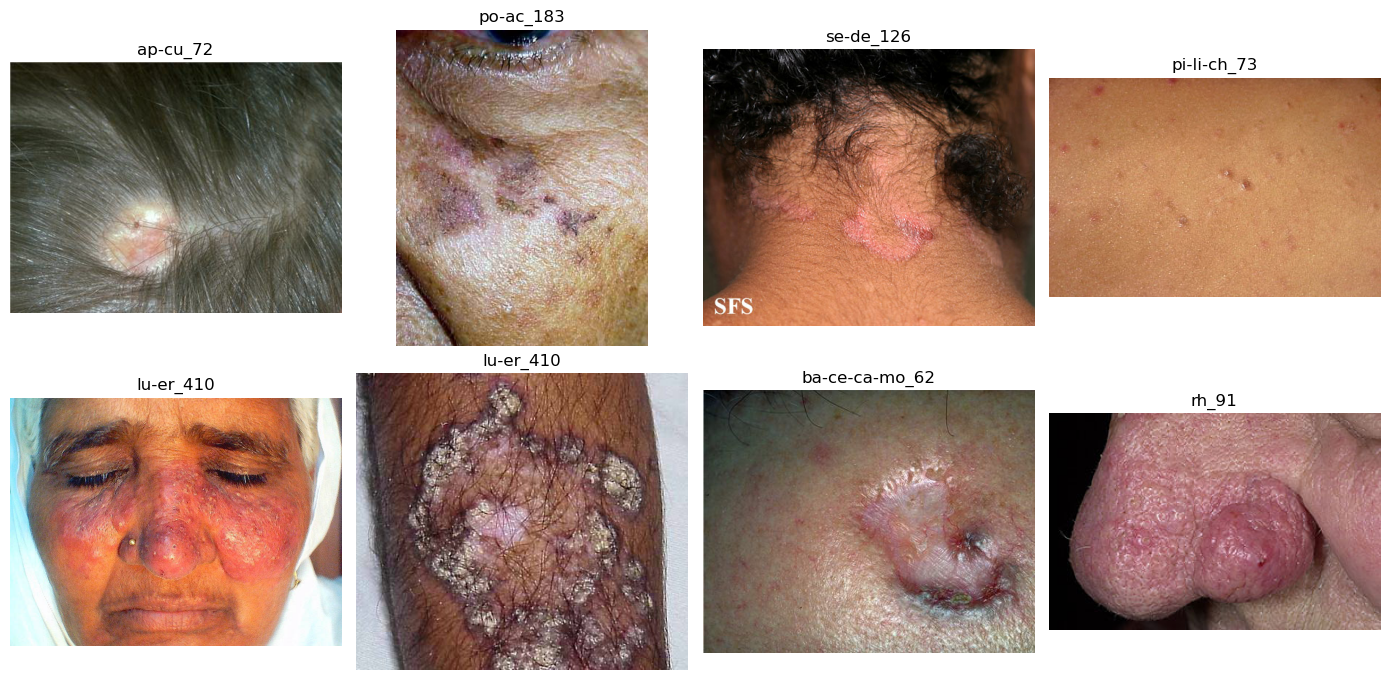

In [12]:
def validate_image(path: Path) -> Tuple[bool, str]:
    try:
        with Image.open(path) as img:
            img = img.convert('RGB') if img.mode in ['L','RGBA','P'] else img
            arr = np.array(img)
            h, w = arr.shape[0], arr.shape[1]
            if w < 50 or h < 50: return False, 'too_small'
            if float(np.std(arr)) <= 5.0: return False, 'blank'
            if max(w, h) / max(1, min(w, h)) >= 5: return False, 'extreme_aspect_ratio'
        return True, 'ok'
    except Exception:
        return False, 'corrupt'

fitz_valid_paths, fitz_invalid_paths = [], []
breakdown = Counter()
for p in tqdm(fitz_downloaded_paths, desc='Validating Fitz images'):
    ok, reason = validate_image(Path(p))
    if ok:
        fitz_valid_paths.append(p)
    else:
        fitz_invalid_paths.append({'image_path': p, 'reason': reason})
        breakdown[reason] += 1

print('[INFO] Total checked:', len(fitz_downloaded_paths))
print('[INFO] Valid count:', len(fitz_valid_paths))
print('[INFO] Invalid count:', len(fitz_invalid_paths))
print('[INFO] Invalid breakdown:', {'corrupt files': breakdown.get('corrupt', 0), 'too small': breakdown.get('too_small', 0), 'blank/near-blank': breakdown.get('blank', 0), 'extreme aspect ratio': breakdown.get('extreme_aspect_ratio', 0)})

if fitz_valid_paths:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(fitz_valid_paths), size=min(8, len(fitz_valid_paths)), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(idx):
            p = Path(fitz_valid_paths[int(idx[i])])
            with Image.open(p) as im: ax.imshow(im.convert('RGB'))
            ax.set_title(p.parent.name)
        ax.axis('off')
    plt.tight_layout(); plt.show()

## Cell 6 — Build Fitzpatrick records dataframe
Builds cleaned Fitz dataframe using metadata partition/fitzpatrick and local file matching.

Building Fitz records: 100%|██████████| 16577/16577 [00:00<00:00, 139268.81it/s]


,image_path,unified_label,fst_group,split,dataset_source,has_disease_label
0,data\Fitzpatrick17k_CategorizedAbbrvs\Categori...,ECZEMA,1,train,fitzpatrick17k,True
1,data\Fitzpatrick17k_CategorizedAbbrvs\Categori...,ECZEMA,1,train,fitzpatrick17k,True
2,data\Fitzpatrick17k_CategorizedAbbrvs\Categori...,ECZEMA,1,train,fitzpatrick17k,True
3,data\Fitzpatrick17k_CategorizedAbbrvs\Categori...,ECZEMA,1,test,fitzpatrick17k,True
4,data\Fitzpatrick17k_CategorizedAbbrvs\Categori...,ECZEMA,1,test,fitzpatrick17k,True


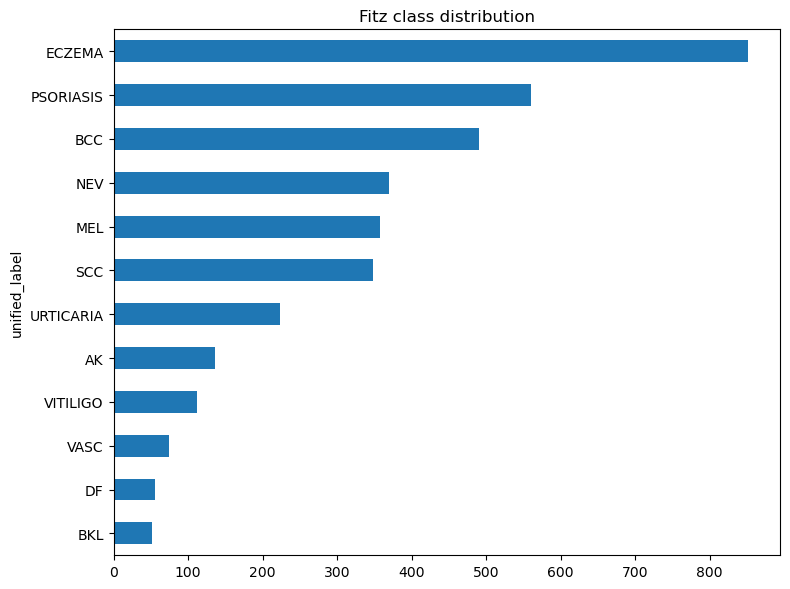

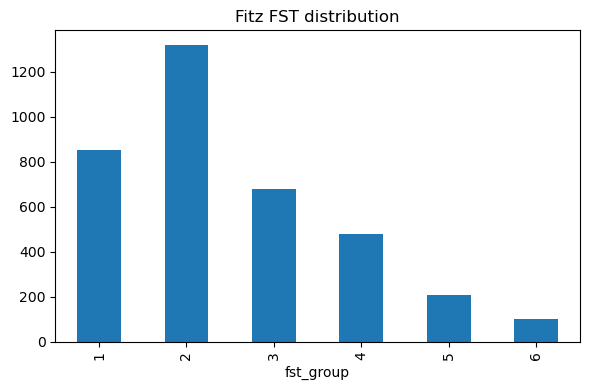

Saved: stage3_fitzpatrick.csv — 3632 records


In [13]:
meta_lookup = {}
for _, r in df_fitz.iterrows():
    fname = Path(str(r.get('new_img_name', ''))).name
    if not fname:
        continue
    raw_diag = str(r.get('label', '')).strip()
    meta_lookup[fname] = {
        'unified_label': FITZ_DIAGNOSIS_MAP.get(raw_diag, map_diagnosis_keyword(raw_diag)),
        'fst_group': r.get('fitzpatrick', np.nan),
        'split': r.get('partition', 'train'),
    }

rows = []
for pstr in tqdm(fitz_valid_paths, desc='Building Fitz records'):
    p = Path(pstr)
    m = meta_lookup.get(p.name)
    if m is None:
        continue
    if m['unified_label'] == UNKNOWN_LABEL:
        continue
    fst = pd.to_numeric(m['fst_group'], errors='coerce')
    if pd.isna(fst) or int(fst) <= 0:
        continue
    rows.append({'image_path': str(p), 'unified_label': m['unified_label'], 'fst_group': int(fst), 'split': str(m['split']), 'dataset_source': 'fitzpatrick17k', 'has_disease_label': True})

df_fitz_clean = pd.DataFrame(rows)
display(df_fitz_clean.head(5))

if not df_fitz_clean.empty:
    df_fitz_clean['unified_label'].value_counts().sort_values().plot(kind='barh', figsize=(8,6), title='Fitz class distribution')
    plt.tight_layout(); plt.show()
    df_fitz_clean['fst_group'].value_counts().sort_index().plot(kind='bar', figsize=(6,4), title='Fitz FST distribution')
    plt.tight_layout(); plt.show()

df_fitz_clean.to_csv(OUTPUT_DIR / 'stage3_fitzpatrick.csv', index=False)
print(f"Saved: stage3_fitzpatrick.csv — {len(df_fitz_clean)} records")

## Cell 7 — Scan DermNet folder structure
Scans DermNet train/test folders and previews sample images.

Scanning DermNet: 100%|██████████| 19559/19559 [00:00<00:00, 88255.30it/s]


[INFO] Total images found: 19559
[INFO] Total unique condition folder names found: 23
[INFO] Unique folders: ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other 

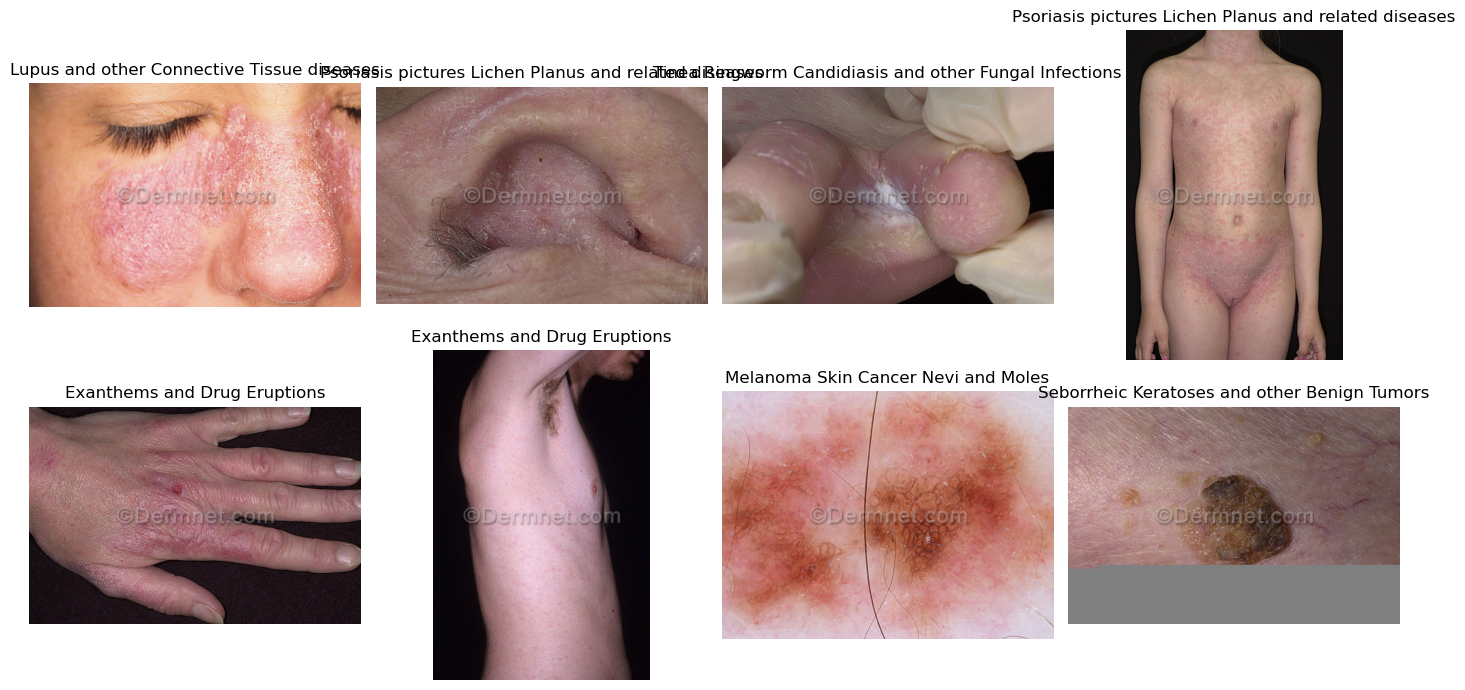

In [14]:
dermnet_records = []
for p in tqdm([x for x in DERMNET_DIR.rglob('*') if x.suffix.lower() in {'.jpg','.jpeg','.png'}], desc='Scanning DermNet'):
    split = p.parts[-3].lower() if len(p.parts) >= 3 and p.parts[-3].lower() in {'train','test','val'} else 'train'
    dermnet_records.append({'image_path': str(p), 'condition_label': p.parent.name, 'split': split})

u = sorted({r['condition_label'] for r in dermnet_records})
print('[INFO] Total images found:', len(dermnet_records))
print('[INFO] Total unique condition folder names found:', len(u))
print('[INFO] Unique folders:', u)

if dermnet_records:
    rng = np.random.default_rng(42)
    ids = rng.choice(len(dermnet_records), size=min(8, len(dermnet_records)), replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(ids):
            rec = dermnet_records[int(ids[i])]
            with Image.open(rec['image_path']) as im: ax.imshow(im.convert('RGB'))
            ax.set_title(rec['condition_label'])
        ax.axis('off')
    plt.tight_layout(); plt.show()

## Cell 8 — Build and review DermNet label map
Maps DermNet folders to unified labels and highlights UNKNOWN rows.

In [18]:
def map_dermnet(raw: str) -> str:
    s = str(raw).lower()
    if 'melanoma' in s: return 'MEL'
    if 'basal cell' in s: return 'BCC'
    if 'squamous' in s: return 'SCC'
    if 'actinic' in s: return 'AK'
    if any(k in s for k in ['nevus','mole','nevi']): return 'NEV'
    if 'seborrheic' in s: return 'BKL'
    if 'dermatofibroma' in s: return 'DF'
    if any(k in s for k in ['vascular','angioma','hemangioma']): return 'VASC'
    if 'keratosis sebaceous' in s: return 'SEK'
    if any(k in s for k in ['tinea','ringworm','dermatophyt']): return 'TINEA'
    if 'psoriasis' in s: return 'PSORIASIS'
    if 'vitiligo' in s: return 'VITILIGO'
    if any(k in s for k in ['melasma','chloasma']): return 'MELASMA'
    if any(k in s for k in ['fungal','candida','onychomycosis']): return 'FUNGAL'
    if any(k in s for k in ['eczema','dermatitis','atopic']): return 'ECZEMA'
    if any(k in s for k in ['urticaria','hives']): return 'URTICARIA'
    return UNKNOWN_LABEL

cnt = Counter([r['condition_label'] for r in dermnet_records])
DERMNET_LABEL_MAP = {k: map_dermnet(k) for k in sorted(cnt.keys())}
DERMNET_LABEL_MAP.update({
    'Nail Fungus and other Nail Disease': 'FUNGAL',
    'Vasculitis Photos': 'VASC',
    'Light Diseases and Disorders of Pigmentation': 'VITILIGO',  # broad proxy
})
df_derm_map = pd.DataFrame({'folder_name': list(DERMNET_LABEL_MAP.keys()), 'mapped_label': list(DERMNET_LABEL_MAP.values())})
df_derm_map['image_count'] = df_derm_map['folder_name'].map(cnt)
df_derm_map = df_derm_map.sort_values(['mapped_label','folder_name']).reset_index(drop=True)

display(df_derm_map.style.apply(lambda r: ['background-color:#ffcccc' if r['mapped_label']==UNKNOWN_LABEL else '' for _ in r], axis=1))
print('[INFO] Total images excluded due to UNKNOWN mapping:', int(df_derm_map.loc[df_derm_map['mapped_label']==UNKNOWN_LABEL, 'image_count'].sum()))
# ── REVIEW THIS OUTPUT CAREFULLY ──────────────────
# If any folder is mapped incorrectly, edit
# DERMNET_LABEL_MAP dict directly in this cell
# and re-run before proceeding to Cell 9.
# ──────────────────────────────────────────────────

,folder_name,mapped_label,image_count
0,Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions,BCC,1437
1,Seborrheic Keratoses and other Benign Tumors,BKL,1714
2,Atopic Dermatitis Photos,ECZEMA,612
3,Eczema Photos,ECZEMA,1544
4,Poison Ivy Photos and other Contact Dermatitis,ECZEMA,325
5,Nail Fungus and other Nail Disease,FUNGAL,1301
6,Melanoma Skin Cancer Nevi and Moles,MEL,579
7,Psoriasis pictures Lichen Planus and related diseases,PSORIASIS,1757
8,Tinea Ringworm Candidiasis and other Fungal Infections,TINEA,1625
9,Acne and Rosacea Photos,UNKNOWN,1152


[INFO] Total images excluded due to UNKNOWN mapping: 6565


## Cell 9 — Validate and build DermNet records
Validates DermNet images and writes cleaned DermNet CSV.

Validating DermNet: 100%|██████████| 19559/19559 [02:35<00:00, 125.91it/s] 


,image_path,unified_label,fst_group,split,dataset_source,has_disease_label
0,data\DermNet\test\Actinic Keratosis Basal Cell...,BCC,0,test,dermnet,True
1,data\DermNet\test\Actinic Keratosis Basal Cell...,BCC,0,test,dermnet,True
2,data\DermNet\test\Actinic Keratosis Basal Cell...,BCC,0,test,dermnet,True
3,data\DermNet\test\Actinic Keratosis Basal Cell...,BCC,0,test,dermnet,True
4,data\DermNet\test\Actinic Keratosis Basal Cell...,BCC,0,test,dermnet,True


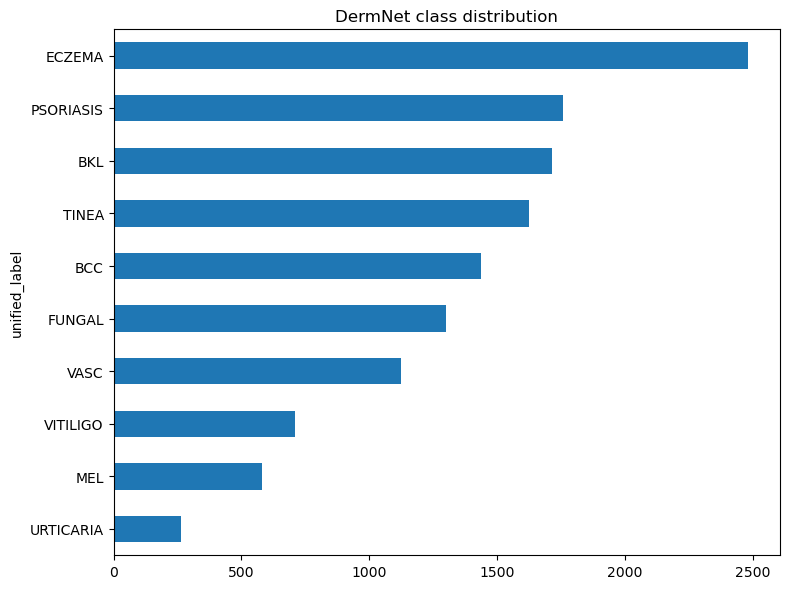

Saved: stage3_dermnet.csv — 12994 records


In [19]:
rows, bad = [], Counter()
for rec in tqdm(dermnet_records, desc='Validating DermNet'):
    u = DERMNET_LABEL_MAP.get(rec['condition_label'], UNKNOWN_LABEL)
    if u == UNKNOWN_LABEL:
        continue
    ok, reason = validate_image(Path(rec['image_path']))
    if not ok:
        bad[reason] += 1
        continue
    rows.append({'image_path': rec['image_path'], 'unified_label': u, 'fst_group': 0, 'split': rec['split'], 'dataset_source': 'dermnet', 'has_disease_label': True})

df_dermnet_clean = pd.DataFrame(rows)
display(df_dermnet_clean.head(5))
if not df_dermnet_clean.empty:
    df_dermnet_clean['unified_label'].value_counts().sort_values().plot(kind='barh', figsize=(8,6), title='DermNet class distribution')
    plt.tight_layout(); plt.show()
df_dermnet_clean.to_csv(OUTPUT_DIR / 'stage3_dermnet.csv', index=False)
print(f"Saved: stage3_dermnet.csv — {len(df_dermnet_clean)} records")

## Cell 10 — Merge and final check
Merges Fitz + DermNet CSVs, reports stats, warns on low-sample classes, saves merged CSV.

[INFO] Duplicate image_path dropped: 0
[INFO] Total images: 16626


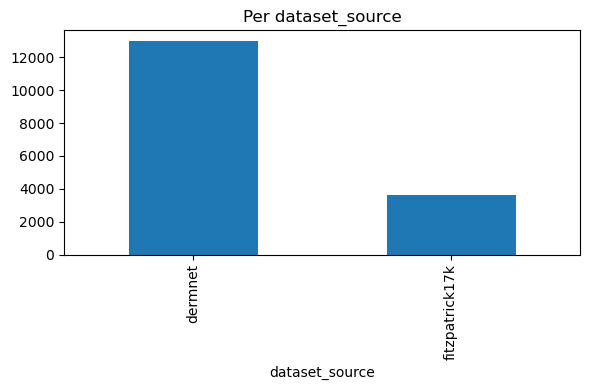

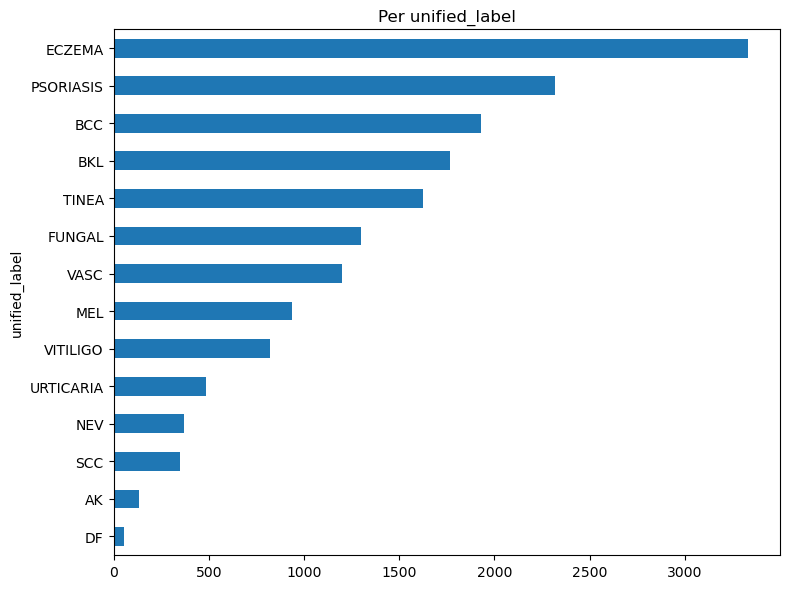

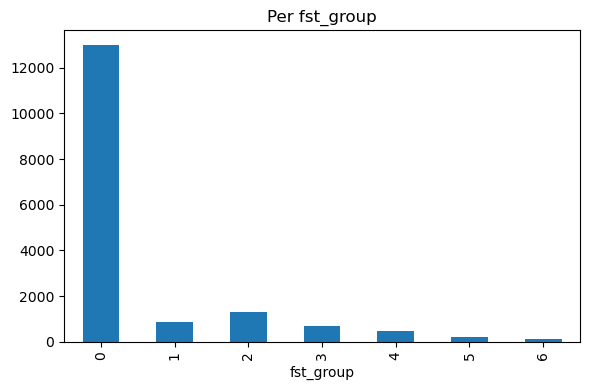

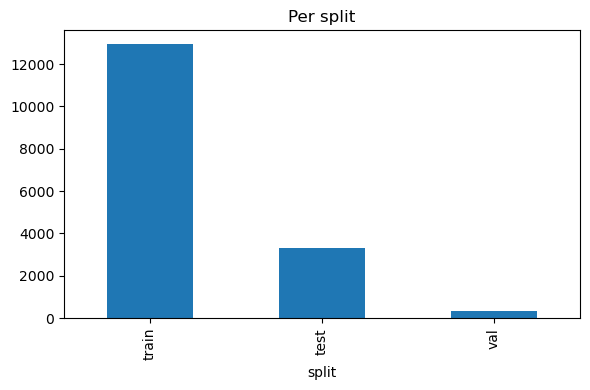

stage3_merged.csv ready — 16626 records
Fitzpatrick: 3632 | DermNet: 12994
Ready for Stage 3 training.


In [20]:
df_f = pd.read_csv(OUTPUT_DIR / 'stage3_fitzpatrick.csv')
df_d = pd.read_csv(OUTPUT_DIR / 'stage3_dermnet.csv')
if list(df_f.columns) != list(df_d.columns):
    raise ValueError(f"Schema mismatch: {list(df_f.columns)} vs {list(df_d.columns)}")
df_merged = pd.concat([df_f, df_d], ignore_index=True)
before = len(df_merged)
df_merged = df_merged.drop_duplicates(subset=['image_path']).reset_index(drop=True)
print('[INFO] Duplicate image_path dropped:', before - len(df_merged))
print('[INFO] Total images:', len(df_merged))

df_merged['dataset_source'].value_counts().plot(kind='bar', figsize=(6,4), title='Per dataset_source')
plt.tight_layout(); plt.show()
df_merged['unified_label'].value_counts().sort_values().plot(kind='barh', figsize=(8,6), title='Per unified_label')
plt.tight_layout(); plt.show()
df_merged['fst_group'].value_counts().sort_index().plot(kind='bar', figsize=(6,4), title='Per fst_group')
plt.tight_layout(); plt.show()
df_merged['split'].astype(str).value_counts().plot(kind='bar', figsize=(6,4), title='Per split')
plt.tight_layout(); plt.show()

low = df_merged['unified_label'].value_counts()
low = low[low < 50]
if not low.empty:
    print('[WARNING] Classes with <50 samples:')
    print(low)

df_merged.to_csv(OUTPUT_DIR / 'stage3_merged.csv', index=False)
n_fitz = int((df_merged['dataset_source']=='fitzpatrick17k').sum())
n_derm = int((df_merged['dataset_source']=='dermnet').sum())
print(f"stage3_merged.csv ready — {len(df_merged)} records")
print(f"Fitzpatrick: {n_fitz} | DermNet: {n_derm}")
print('Ready for Stage 3 training.')

## Cell 11 — Preprocessing summary report
Writes final preprocessing report text file with key counts and warnings.

In [21]:
df_m = pd.read_csv(OUTPUT_DIR / 'stage3_merged.csv')
class_counts = df_m['unified_label'].value_counts()
fst_counts = df_m['fst_group'].value_counts().sort_index()
low = class_counts[class_counts < 50]
failed_file = OUTPUT_DIR / 'failed_downloads.txt'
failed_lines = failed_file.read_text(encoding='utf-8', errors='ignore').splitlines() if failed_file.exists() else []
unknown_fitz = sorted([k for k,v in FITZ_DIAGNOSIS_MAP.items() if v == UNKNOWN_LABEL])
unknown_derm = sorted([k for k,v in DERMNET_LABEL_MAP.items() if v == UNKNOWN_LABEL])

lines = []
lines.append(f'Run timestamp: {datetime.now().isoformat()}')
lines.append('')
lines.append(f"Fitzpatrick final count: {int((df_m['dataset_source']=='fitzpatrick17k').sum())}")
lines.append(f"DermNet final count: {int((df_m['dataset_source']=='dermnet').sum())}")
lines.append('')
lines.append('Class distribution table')
lines.append(class_counts.to_string())
lines.append('')
lines.append('FST distribution table')
lines.append(fst_counts.to_string())
lines.append('')
lines.append('Failed Fitzpatrick download URLs')
lines.extend(failed_lines if failed_lines else ['None (local ZIP mode)'])
lines.append('')
lines.append('UNKNOWN labels excluded (Fitzpatrick)')
lines.extend(unknown_fitz if unknown_fitz else ['None'])
lines.append('')
lines.append('UNKNOWN labels excluded (DermNet)')
lines.extend(unknown_derm if unknown_derm else ['None'])
lines.append('')
lines.append('Classes with < 50 samples (warnings)')
if low.empty:
    lines.append('None')
else:
    lines.extend([f'{k}: {v}' for k,v in low.items()])

(OUTPUT_DIR / 'preprocessing_report.txt').write_text('\n'.join(lines), encoding='utf-8')
print('Report saved to preprocessing_report.txt')

Report saved to preprocessing_report.txt
